In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/sample_submission.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv


In [2]:
"""
=======================================================
IEEE-CIS Fraud Detection
Model 3: Tree-Based Models
=======================================================
What this notebook covers:
  1. Decision Tree (baseline tree)
  2. Random Forest
  3. XGBoost
  4. LightGBM
  5. CatBoost
  6. Compare all models
  7. Feature importance analysis
"""

# ──────────────────────────────────────────────────────
# CELL 1: IMPORTS
# ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import gc

# Tree models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve,
                             average_precision_score,
                             classification_report)
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8-whitegrid")
print("✅ All imports done!")



✅ All imports done!


In [3]:

# ──────────────────────────────────────────────────────
# CELL 2: LOAD DATA
# ──────────────────────────────────────────────────────
train_transaction = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv")
train_identity    = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv")
test_transaction  = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv")
test_identity     = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv")

train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test  = test_transaction.merge(test_identity,   on="TransactionID", how="left")

# ── Keep representative V columns ────────────────────
v_keep = [
    1, 3, 4, 6, 8, 11,
    13, 14, 17, 20, 23, 26, 27, 30,
    36, 37, 40, 41, 44, 47, 48,
    54, 56, 59, 62, 65, 67, 68, 70,
    76, 78, 80, 82, 86, 88, 89, 91,
    96, 98, 99, 104,
    107, 108, 111, 115, 117, 120, 121, 123,
    124, 127, 129, 130, 136,
    294, 284, 285, 286, 291, 297,
    303, 305, 307, 309, 310, 320
]
v_keep_cols = [f'V{i}' for i in v_keep]
v_all_cols  = [f'V{i}' for i in range(1, 340) if f'V{i}' in train.columns]
v_drop_cols = [c for c in v_all_cols if c not in v_keep_cols]

train = train.drop(columns=v_drop_cols, errors='ignore')
test  = test.drop(columns=v_drop_cols,  errors='ignore')


In [6]:

# ── Reduce memory ────────────────────────────────────
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

train = reduce_memory(train)
test  = reduce_memory(test)
gc.collect()

print(f"✅ Train: {train.shape}")
print(f"✅ Test:  {test.shape}")
print(f"✅ Fraud rate: {train['isFraud'].mean()*100:.2f}%")


✅ Train: (590540, 161)
✅ Test:  (506691, 160)
✅ Fraud rate: 3.50%


In [4]:

# ──────────────────────────────────────────────────────
# CELL 3: WHY TREES ARE DIFFERENT FROM LR/NN
# ──────────────────────────────────────────────────────
"""
KEY DIFFERENCES — Trees vs LR vs NN:

                  Decision Tree  Random Forest  XGBoost  LightGBM
─────────────────────────────────────────────────────────────────
Scaling needed?   ❌ No          ❌ No          ❌ No    ❌ No
Missing values?   ❌ Need impute ❌ Need impute ✅ Native✅ Native
Categorical?      ❌ Need encode ❌ Need encode ❌ Encode✅ Native
Interactions?     ✅ Automatic   ✅ Automatic   ✅ Auto  ✅ Auto
Overfitting?      ⚠️ High        ✅ Low(ensemble)✅ Low  ✅ Low
Speed?            ✅ Fast        ⚠️ Medium      ✅ Fast  ✅ Fastest
AUC on this data? ~0.80         ~0.88          ~0.93   ~0.935

KEY INSIGHT:
  Trees split on ONE feature at a time
  → Don't need scaling (no distance calculations)
  → Don't need interaction features (tree does it)
  → Handle missing values differently

  XGBoost/LightGBM: learn which direction to send
  missing values during training
  → -999 imputation acceptable
"""
print("📚 Tree model characteristics loaded")


📚 Tree model characteristics loaded


In [5]:
def engineer_features_trees(df, is_train=True, fit_data=None):
    """
    Feature engineering for Tree Models
    Key differences from LR/NN:
      ✅ No scaling needed
      ✅ Use -999 for missing (XGBoost handles natively)
      ✅ Label encode categoricals (not one-hot)
      ✅ Keep interaction features (still helps)
      ✅ No need for log transforms (trees don't care about scale)
         But log transforms still help with extreme outliers
    """
    df = df.copy()
    df = df.reset_index(drop=True)

    # ── Amount features ──────────────────────────────
    df['amt_log']      = np.log1p(df['TransactionAmt'])
    df['amt_decimal']  = df['TransactionAmt'] - df['TransactionAmt'].astype(int)
    df['is_round']     = (df['amt_decimal'] == 0).astype(int)
    df['is_micro_txn'] = (df['TransactionAmt'] < 10).astype(int)
    df['is_sweet_spot']= ((df['TransactionAmt'] >= 200) &
                          (df['TransactionAmt'] <= 500)).astype(int)

    # ── Time features ────────────────────────────────
    df['hour']         = (df['TransactionDT'] // 3600) % 24
    df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
    df['day']          = df['TransactionDT'] / 86400
    df['is_night']     = (df['hour'].isin([23,0,1,2,3,4,5])).astype(int)
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['is_monday']    = (df['day_of_week'] == 0).astype(int)
    df['is_9am']       = (df['hour'] == 9).astype(int)
    df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)

    # ── Email features ───────────────────────────────
    free_emails      = ['gmail.com','yahoo.com','hotmail.com','outlook.com']
    high_risk_emails = ['protonmail.com','anonymous.com']

    df['is_free_email']     = df['P_emaildomain'].isin(free_emails).astype(int)
    df['is_highrisk_email'] = df['P_emaildomain'].isin(high_risk_emails).astype(int)
    df['email_match']       = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
    df['email_p_missing']   = df['P_emaildomain'].isna().astype(int)
    df['email_r_missing']   = df['R_emaildomain'].isna().astype(int)

    # ── Card risk scores ─────────────────────────────
    card4_risk = {'mastercard':0.030,'discover':0.026,
                  'visa':0.025,'american express':0.010}
    card6_risk = {'credit':0.037,'debit':0.020,
                  'charge card':0.001,'debit or credit':0.015}
    df['card4_risk']    = df['card4'].map(card4_risk).fillna(0.025)
    df['card6_risk']    = df['card6'].map(card6_risk).fillna(0.020)
    df['combined_risk'] = df['card4_risk'] * df['card6_risk']

    # ── Missing value flags ──────────────────────────
    df['null_count']    = df.isnull().sum(axis=1)
    df['addr_missing']  = df['addr1'].isna().astype(int)
    df['dist1_missing'] = df['dist1'].isna().astype(int)
    df['D1_missing']    = df['D1'].isna().astype(int)
    df['D11_missing']   = df['D11'].isna().astype(int)

    # ── D column features ────────────────────────────
    D1_filled          = df['D1'].fillna(-1)
    df['is_rapid_txn'] = (D1_filled < 1).astype(int)
    df['is_dormant']   = (D1_filled > 180).astype(int)
    df['D1_log']       = np.log1p(df['D1'].fillna(0))
    df['D11_log']      = np.log1p(df['D11'].fillna(0))

    # ── M column mismatch ────────────────────────────
    m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df.columns]
    df['m_false_count'] = (df[m_cols] == 'F').sum(axis=1)
    df['m_true_count']  = (df[m_cols] == 'T').sum(axis=1)
    df['m_missing']     = df[m_cols].isna().sum(axis=1)

    # ── Frequency encoding ───────────────────────────
    source    = df if is_train else fit_data
    freq_cols = ['card1','card2','addr1','P_emaildomain',
                 'R_emaildomain','DeviceInfo','DeviceType']
    for col in freq_cols:
        if col in df.columns and col in source.columns:
            freq = source[col].value_counts(normalize=True)
            df[f'{col}_freq'] = df[col].map(freq).fillna(0)

    # ── GroupBy aggregation features ─────────────────
    source_data = df if is_train else fit_data
    for col in ['card1','card2','addr1']:
        if col in df.columns:
            global_mean = source_data['TransactionAmt'].mean()
            if is_train:
                df[f'{col}_amt_mean']  = df.groupby(col)['TransactionAmt'].transform('mean')
                df[f'{col}_amt_std']   = df.groupby(col)['TransactionAmt'].transform('std').fillna(0)
                df[f'{col}_count']     = df.groupby(col)['TransactionAmt'].transform('count')
                df[f'{col}_amt_max']   = df.groupby(col)['TransactionAmt'].transform('max')
            else:
                map_mean  = source_data.groupby(col)['TransactionAmt'].mean()
                map_std   = source_data.groupby(col)['TransactionAmt'].std().fillna(0)
                map_count = source_data.groupby(col)['TransactionAmt'].count()
                map_max   = source_data.groupby(col)['TransactionAmt'].max()
                df[f'{col}_amt_mean']  = df[col].map(map_mean).fillna(global_mean)
                df[f'{col}_amt_std']   = df[col].map(map_std).fillna(0)
                df[f'{col}_count']     = df[col].map(map_count).fillna(0)
                df[f'{col}_amt_max']   = df[col].map(map_max).fillna(global_mean)

            df[f'{col}_amt_ratio']     = df['TransactionAmt'] / (df[f'{col}_amt_mean'] + 1)
            df[f'{col}_amt_ratio_log'] = np.log1p(df[f'{col}_amt_ratio'])

    # ── UID features ─────────────────────────────────
    df['D1n'] = df['day'] - df['D1'].fillna(0)
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].fillna(-1).astype(str) + '_' +
                 np.floor(df['D1n']).astype(str))

    if is_train:
        df['uid_amt_mean']  = df.groupby('uid')['TransactionAmt'].transform('mean')
        df['uid_amt_std']   = df.groupby('uid')['TransactionAmt'].transform('std').fillna(0)
        df['uid_count']     = df.groupby('uid')['TransactionAmt'].transform('count')
    else:
        fd        = fit_data.copy().reset_index(drop=True)
        fd['day'] = fd['TransactionDT'] / 86400
        fd['D1n'] = fd['day'] - fd['D1'].fillna(0)
        fd['uid'] = (fd['card1'].astype(str) + '_' +
                     fd['addr1'].fillna(-1).astype(str) + '_' +
                     np.floor(fd['D1n']).astype(str))
        uid_map_m = fd.groupby('uid')['TransactionAmt'].mean()
        uid_map_s = fd.groupby('uid')['TransactionAmt'].std().fillna(0)
        uid_map_c = fd.groupby('uid')['TransactionAmt'].count()
        df['uid_amt_mean']  = df['uid'].map(uid_map_m).fillna(fit_data['TransactionAmt'].mean())
        df['uid_amt_std']   = df['uid'].map(uid_map_s).fillna(0)
        df['uid_count']     = df['uid'].map(uid_map_c).fillna(0)

    df['uid_amt_ratio']     = df['TransactionAmt'] / (df['uid_amt_mean'] + 1)
    df['uid_amt_ratio_log'] = np.log1p(df['uid_amt_ratio'])
    df.drop(['uid','D1n','day'], axis=1, inplace=True, errors='ignore')

    # ── Label encode categoricals ────────────────────
    # ✅ Fix: always include 'unknown' in fit so test unseen values work
    cat_cols = ['card4','card6','ProductCD','DeviceType',
                'P_emaildomain','R_emaildomain','DeviceInfo']

    # Source is always train data (fit_data for test, df for train)
    source_for_enc = df if is_train else fit_data

    for col in cat_cols:
        if col in df.columns:

            # Fill NaN with 'unknown' in both df and source
            df[col]             = df[col].astype(str).fillna('unknown')
            source_for_enc[col] = source_for_enc[col].astype(str).fillna('unknown')

            # Get unique values from source + add 'unknown' explicitly
            # so unseen test values can always map to it safely
            unique_vals = list(source_for_enc[col].unique())
            if 'unknown' not in unique_vals:
                unique_vals.append('unknown')   # ✅ always include 'unknown'

            # Fit encoder on source values including 'unknown'
            le = LabelEncoder()
            le.fit(unique_vals)

            # Map any unseen values in df → 'unknown' before transform
            known_classes = set(le.classes_)
            df[col] = df[col].apply(
                lambda x: x if x in known_classes else 'unknown'
            )

            # Now transform safely — 'unknown' is always in classes_
            df[col] = le.transform(df[col])

    print(f"  ✅ Features: {df.shape[1]} columns")
    return df


print("Engineering train features...")
train_fe = engineer_features_trees(train, is_train=True)
print("Engineering test features...")
test_fe  = engineer_features_trees(test,  is_train=False, fit_data=train)
gc.collect()


Engineering train features...
  ✅ Features: 224 columns
Engineering test features...
  ✅ Features: 223 columns


60

In [6]:

# ──────────────────────────────────────────────────────
# CELL 5: PREPARE DATA FOR TREES
# ──────────────────────────────────────────────────────
drop_cols = [
    'TransactionID','TransactionDT','isFraud',
    'card1','card2','card3','card5',
    'addr1','addr2',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9'
]

# Get common columns between train and test
common_cols = set(train_fe.columns) & set(test_fe.columns)
feature_cols = [
    c for c in train_fe.columns
    if c in common_cols
    and c not in drop_cols
    and pd.api.types.is_numeric_dtype(train_fe[c])
]

print(f"✅ Total features: {len(feature_cols)}")

X      = train_fe[feature_cols].copy()
y      = train['isFraud'].copy()
X_test = test_fe[feature_cols].copy()

# ── For XGBoost/LightGBM: fill NaN with -999 ─────────
# These models handle -999 as "missing" natively
X_xgb      = X.fillna(-999)
X_test_xgb = X_test.fillna(-999)

# ── For Decision Tree/Random Forest: fill with median ─
medians    = X.median()
X_tree     = X.fillna(medians)
X_test_tree= X_test.fillna(medians)

print(f"✅ X shape: {X.shape}")
print(f"✅ Fraud rate: {y.mean()*100:.2f}%")
print(f"✅ Class ratio: {(y==0).sum()}/{(y==1).sum()} = {(y==0).sum()/(y==1).sum():.0f}:1")




✅ Total features: 168
✅ X shape: (590540, 168)
✅ Fraud rate: 3.50%
✅ Class ratio: 569877/20663 = 28:1


In [7]:

# ──────────────────────────────────────────────────────
# CELL 6: CROSS VALIDATION HELPER
# ──────────────────────────────────────────────────────
def cross_validate_model(model, X, y, model_name, n_splits=5):
    """
    Train and evaluate any sklearn-compatible model
    using StratifiedKFold cross validation
    Returns: oof_preds, fold_aucs, oof_auc, feature_importances
    """
    skf        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds  = np.zeros(len(X))
    fold_aucs  = []
    importances= np.zeros(len(feature_cols))

    print(f"\nTraining {model_name}...")
    print("-" * 50)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr  = X.iloc[tr_idx]
        y_tr  = y.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        val_pred           = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_pred
        fold_auc           = roc_auc_score(y_val, val_pred)
        fold_aucs.append(fold_auc)

        # Accumulate feature importance
        if hasattr(model, 'feature_importances_'):
            importances += model.feature_importances_

        print(f"  Fold {fold}: AUC = {fold_auc:.5f}")

    oof_auc = roc_auc_score(y, oof_preds)
    importances /= n_splits  # average across folds

    print(f"\n  Mean Fold AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")
    print(f"  OOF AUC:       {oof_auc:.5f}")

    return oof_preds, fold_aucs, oof_auc, importances



In [8]:

# ──────────────────────────────────────────────────────
# CELL 7: MODEL 1 — DECISION TREE
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 1: DECISION TREE")
print("=" * 60)
print("""
Decision Tree:
  Splits data on single features one at a time
  "Is amt_ratio > 2.5? → YES: fraud, NO: check next"

  WITHOUT regularization:
    Grows until every leaf has 1 sample
    → Memorizes training data perfectly
    → AUC on train = 1.0
    → AUC on test  = 0.60 (terrible!)
    → Classic overfitting

  Regularization parameters:
    max_depth:        limit tree depth
    min_samples_leaf: minimum samples per leaf
    min_samples_split:minimum samples to split node
    max_features:     fraction of features per split
""")

# Overfitting example
dt_overfit = DecisionTreeClassifier(random_state=42)  # no limits
dt_overfit.fit(X_tree, y)
train_auc_overfit = roc_auc_score(y, dt_overfit.predict_proba(X_tree)[:,1])
print(f"Overfitted tree - Train AUC: {train_auc_overfit:.5f} (memorized!)")

# Regularized Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth        = 8,    # limit depth → prevents memorization
    min_samples_leaf = 100,  # each leaf needs 100+ samples
    min_samples_split= 200,  # need 200+ to split a node
    max_features     = 0.8,  # use 80% of features per split
    class_weight     = 'balanced',
    random_state     = 42
)

oof_dt, aucs_dt, auc_dt, imp_dt = cross_validate_model(
    dt_model, X_tree, y, "Decision Tree", n_splits=5
)




MODEL 1: DECISION TREE

Decision Tree:
  Splits data on single features one at a time
  "Is amt_ratio > 2.5? → YES: fraud, NO: check next"

  WITHOUT regularization:
    Grows until every leaf has 1 sample
    → Memorizes training data perfectly
    → AUC on train = 1.0
    → AUC on test  = 0.60 (terrible!)
    → Classic overfitting

  Regularization parameters:
    max_depth:        limit tree depth
    min_samples_leaf: minimum samples per leaf
    min_samples_split:minimum samples to split node
    max_features:     fraction of features per split

Overfitted tree - Train AUC: 1.00000 (memorized!)

Training Decision Tree...
--------------------------------------------------
  Fold 1: AUC = 0.86804
  Fold 2: AUC = 0.86827
  Fold 3: AUC = 0.86686
  Fold 4: AUC = 0.86153
  Fold 5: AUC = 0.86461

  Mean Fold AUC: 0.86586 ± 0.00252
  OOF AUC:       0.86649


In [9]:

# ──────────────────────────────────────────────────────
# CELL 8: MODEL 2 — RANDOM FOREST
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 2: RANDOM FOREST")
print("=" * 60)
print("""
Random Forest = many Decision Trees trained on:
  1. Random sample of rows (bagging)
  2. Random subset of features per split

Why better than single tree:
  Single tree: 1 opinion → biased
  100 trees:   100 opinions → averaged → stable

  "Wisdom of the crowd"

Key parameters:
  n_estimators:    number of trees (more = better but slower)
  max_depth:       depth per tree
  min_samples_leaf:min samples per leaf
  max_features:    features per split ('sqrt' = standard)
  n_jobs=-1:       use all CPU cores
""")

rf_model = RandomForestClassifier(
    n_estimators     = 200,       # 200 trees
    max_depth        = 12,        # each tree depth 12
    min_samples_leaf = 50,        # min 50 samples per leaf
    max_features     = 'sqrt',    # sqrt(n_features) per split
    class_weight     = 'balanced',
    n_jobs           = -1,        # all CPU cores
    random_state     = 42
)

oof_rf, aucs_rf, auc_rf, imp_rf = cross_validate_model(
    rf_model, X_tree, y, "Random Forest", n_splits=3  # 3 folds (slower model)
)



MODEL 2: RANDOM FOREST

Random Forest = many Decision Trees trained on:
  1. Random sample of rows (bagging)
  2. Random subset of features per split

Why better than single tree:
  Single tree: 1 opinion → biased
  100 trees:   100 opinions → averaged → stable

  "Wisdom of the crowd"

Key parameters:
  n_estimators:    number of trees (more = better but slower)
  max_depth:       depth per tree
  min_samples_leaf:min samples per leaf
  max_features:    features per split ('sqrt' = standard)
  n_jobs=-1:       use all CPU cores


Training Random Forest...
--------------------------------------------------
  Fold 1: AUC = 0.92270
  Fold 2: AUC = 0.91678
  Fold 3: AUC = 0.91725

  Mean Fold AUC: 0.91891 ± 0.00269
  OOF AUC:       0.91885


In [10]:

# ──────────────────────────────────────────────────────
# CELL 9: MODEL 3 — XGBOOST
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 3: XGBOOST")
print("=" * 60)
print("""
XGBoost = Extreme Gradient Boosting
  Builds trees SEQUENTIALLY
  Each tree corrects errors of previous trees

  Tree 1: rough prediction
  Tree 2: learns from Tree 1's errors
  Tree 3: learns from Tree 1+2 errors
  ...
  Tree 500: final refined prediction

Regularization in XGBoost:
  learning_rate:    smaller = less overfitting (but slower)
  max_depth:        tree depth limit
  subsample:        fraction of rows per tree
  colsample_bytree: fraction of columns per tree
  min_child_weight: min samples in leaf
  reg_alpha:        L1 regularization
  reg_lambda:       L2 regularization
  scale_pos_weight: handles class imbalance
""")

# Calculate class imbalance ratio
scale_pos = int((y == 0).sum() / (y == 1).sum())
print(f"scale_pos_weight = {scale_pos} (fraud is {scale_pos}x rarer)")

xgb_model = XGBClassifier(
    # Tree structure
    n_estimators      = 500,
    max_depth         = 6,          # standard depth
    min_child_weight  = 100,        # min samples in leaf

    # Randomization (prevents overfitting)
    subsample         = 0.8,        # 80% rows per tree
    colsample_bytree  = 0.8,        # 80% features per tree
    colsample_bylevel = 0.8,        # 80% features per level

    # Learning
    learning_rate     = 0.05,       # small = better but slower

    # Regularization
    reg_alpha         = 0.1,        # L1
    reg_lambda        = 1.0,        # L2

    # Imbalance
    scale_pos_weight  = scale_pos,

    # Technical
    tree_method       = 'hist',     # fast histogram method
    device            = 'cuda' if __import__('torch').cuda.is_available() else 'cpu',
    eval_metric       = 'auc',
    random_state      = 42,
    verbosity         = 0
)

oof_xgb, aucs_xgb, auc_xgb, imp_xgb = cross_validate_model(
    xgb_model, X_xgb, y, "XGBoost", n_splits=5
)


MODEL 3: XGBOOST

XGBoost = Extreme Gradient Boosting
  Builds trees SEQUENTIALLY
  Each tree corrects errors of previous trees

  Tree 1: rough prediction
  Tree 2: learns from Tree 1's errors
  Tree 3: learns from Tree 1+2 errors
  ...
  Tree 500: final refined prediction

Regularization in XGBoost:
  learning_rate:    smaller = less overfitting (but slower)
  max_depth:        tree depth limit
  subsample:        fraction of rows per tree
  colsample_bytree: fraction of columns per tree
  min_child_weight: min samples in leaf
  reg_alpha:        L1 regularization
  reg_lambda:       L2 regularization
  scale_pos_weight: handles class imbalance

scale_pos_weight = 27 (fraud is 27x rarer)

Training XGBoost...
--------------------------------------------------
  Fold 1: AUC = 0.95209
  Fold 2: AUC = 0.95230
  Fold 3: AUC = 0.95069
  Fold 4: AUC = 0.95134
  Fold 5: AUC = 0.95146

  Mean Fold AUC: 0.95157 ± 0.00057
  OOF AUC:       0.95155


In [11]:

# ──────────────────────────────────────────────────────
# CELL 10: MODEL 4 — LIGHTGBM
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 4: LIGHTGBM")
print("=" * 60)
print("""
LightGBM = Light Gradient Boosting Machine
  Microsoft's faster alternative to XGBoost

  Key differences from XGBoost:
    Leaf-wise growth (vs level-wise in XGBoost)
    → Finds best leaf to split at each step
    → More accurate but needs regularization
    → Much faster (10x on large datasets)

  Handles categoricals NATIVELY:
    → No need to label encode
    → Finds optimal category splits automatically

  Key parameters:
    num_leaves:      max leaves per tree (main parameter!)
    min_child_samples:min samples per leaf
    feature_fraction: fraction of features per tree
    bagging_fraction: fraction of rows per tree
    lambda_l1/l2:    regularization
    is_unbalance:    handles class imbalance
""")

lgb_model = LGBMClassifier(
    # Tree structure
    n_estimators      = 500,
    num_leaves        = 63,         # 2^max_depth - 1 = 63 for depth 6
    max_depth         = -1,         # -1 = no limit (num_leaves controls)
    min_child_samples = 100,        # min samples per leaf

    # Randomization
    feature_fraction  = 0.8,        # 80% features per tree
    bagging_fraction  = 0.8,        # 80% rows per tree
    bagging_freq      = 5,          # bagging every 5 iterations

    # Learning
    learning_rate     = 0.05,

    # Regularization
    lambda_l1         = 0.1,
    lambda_l2         = 1.0,
    min_gain_to_split = 0.01,       # min improvement to split

    # Imbalance
    is_unbalance      = True,       # handles class imbalance

    # Technical
    device_type       = 'gpu' if __import__('torch').cuda.is_available() else 'cpu',
    n_jobs            = -1,
    random_state      = 42,
    verbosity         = -1
)

oof_lgb, aucs_lgb, auc_lgb, imp_lgb = cross_validate_model(
    lgb_model, X_xgb, y, "LightGBM", n_splits=5
)



MODEL 4: LIGHTGBM

LightGBM = Light Gradient Boosting Machine
  Microsoft's faster alternative to XGBoost

  Key differences from XGBoost:
    Leaf-wise growth (vs level-wise in XGBoost)
    → Finds best leaf to split at each step
    → More accurate but needs regularization
    → Much faster (10x on large datasets)

  Handles categoricals NATIVELY:
    → No need to label encode
    → Finds optimal category splits automatically

  Key parameters:
    num_leaves:      max leaves per tree (main parameter!)
    min_child_samples:min samples per leaf
    feature_fraction: fraction of features per tree
    bagging_fraction: fraction of rows per tree
    lambda_l1/l2:    regularization
    is_unbalance:    handles class imbalance


Training LightGBM...
--------------------------------------------------
  Fold 1: AUC = 0.96481
  Fold 2: AUC = 0.96530
  Fold 3: AUC = 0.96385
  Fold 4: AUC = 0.96558
  Fold 5: AUC = 0.96512

  Mean Fold AUC: 0.96493 ± 0.00060
  OOF AUC:       0.96491


In [12]:

# ──────────────────────────────────────────────────────
# CELL 11: MODEL 5 — CATBOOST
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 5: CATBOOST")
print("=" * 60)
print("""
CatBoost = Categorical Boosting (by Yandex)
  Best for datasets with many categorical features

  Key innovations:
    Ordered boosting: prevents target leakage
    Native categoricals: best handling in industry
    Symmetric trees: faster prediction

  Key parameters:
    iterations:      number of trees
    depth:           tree depth (6-10 typical)
    learning_rate:   step size
    l2_leaf_reg:     L2 regularization
    border_count:    bins for numeric features
    auto_class_weights: handles imbalance
""")

cat_features_idx = []  # CatBoost can handle categoricals natively
                       # but we already label encoded them
                       # so treating all as numeric here

cb_model = CatBoostClassifier(
    iterations        = 500,
    depth             = 6,
    learning_rate     = 0.05,
    l2_leaf_reg       = 3.0,        # L2 regularization
    border_count      = 128,        # bins for numeric features
    bagging_temperature= 1.0,       # randomization
    random_strength   = 1.0,        # noise for split scoring
    auto_class_weights= 'Balanced', # handles class imbalance
    eval_metric       = 'AUC',
    task_type         = 'GPU' if __import__('torch').cuda.is_available() else 'CPU',
    random_seed       = 42,
    verbose           = 0
)

oof_cb, aucs_cb, auc_cb, imp_cb = cross_validate_model(
    cb_model, X_xgb, y, "CatBoost", n_splits=5
)




MODEL 5: CATBOOST

CatBoost = Categorical Boosting (by Yandex)
  Best for datasets with many categorical features

  Key innovations:
    Ordered boosting: prevents target leakage
    Native categoricals: best handling in industry
    Symmetric trees: faster prediction

  Key parameters:
    iterations:      number of trees
    depth:           tree depth (6-10 typical)
    learning_rate:   step size
    l2_leaf_reg:     L2 regularization
    border_count:    bins for numeric features
    auto_class_weights: handles imbalance


Training CatBoost...
--------------------------------------------------
  Fold 1: AUC = 0.93694
  Fold 2: AUC = 0.93708
  Fold 3: AUC = 0.93494
  Fold 4: AUC = 0.93570
  Fold 5: AUC = 0.93558

  Mean Fold AUC: 0.93605 ± 0.00083
  OOF AUC:       0.93602


In [13]:

# ──────────────────────────────────────────────────────
# CELL 12: COMPARE ALL TREE MODELS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("TREE MODEL COMPARISON")
print("=" * 60)

tree_results = {
    'Decision Tree': {'auc': auc_dt,  'fold_aucs': aucs_dt,  'oof': oof_dt,  'imp': imp_dt},
    'Random Forest': {'auc': auc_rf,  'fold_aucs': aucs_rf,  'oof': oof_rf,  'imp': imp_rf},
    'XGBoost':       {'auc': auc_xgb, 'fold_aucs': aucs_xgb, 'oof': oof_xgb, 'imp': imp_xgb},
    'LightGBM':      {'auc': auc_lgb, 'fold_aucs': aucs_lgb, 'oof': oof_lgb, 'imp': imp_lgb},
    'CatBoost':      {'auc': auc_cb,  'fold_aucs': aucs_cb,  'oof': oof_cb,  'imp': imp_cb},
}

print(f"\n{'Model':<16} {'OOF AUC':>10} {'Mean Fold':>10} {'Std':>8}")
print("-" * 48)
for name, res in tree_results.items():
    print(f"{name:<16} {res['auc']:>10.5f} "
          f"{np.mean(res['fold_aucs']):>10.5f} "
          f"{np.std(res['fold_aucs']):>8.5f}")

best_tree = max(tree_results, key=lambda k: tree_results[k]['auc'])
print(f"\n🏆 Best tree model: {best_tree} "
      f"(AUC={tree_results[best_tree]['auc']:.5f})")



TREE MODEL COMPARISON

Model               OOF AUC  Mean Fold      Std
------------------------------------------------
Decision Tree       0.86649    0.86586  0.00252
Random Forest       0.91885    0.91891  0.00269
XGBoost             0.95155    0.95157  0.00057
LightGBM            0.96491    0.96493  0.00060
CatBoost            0.93602    0.93605  0.00083

🏆 Best tree model: LightGBM (AUC=0.96491)


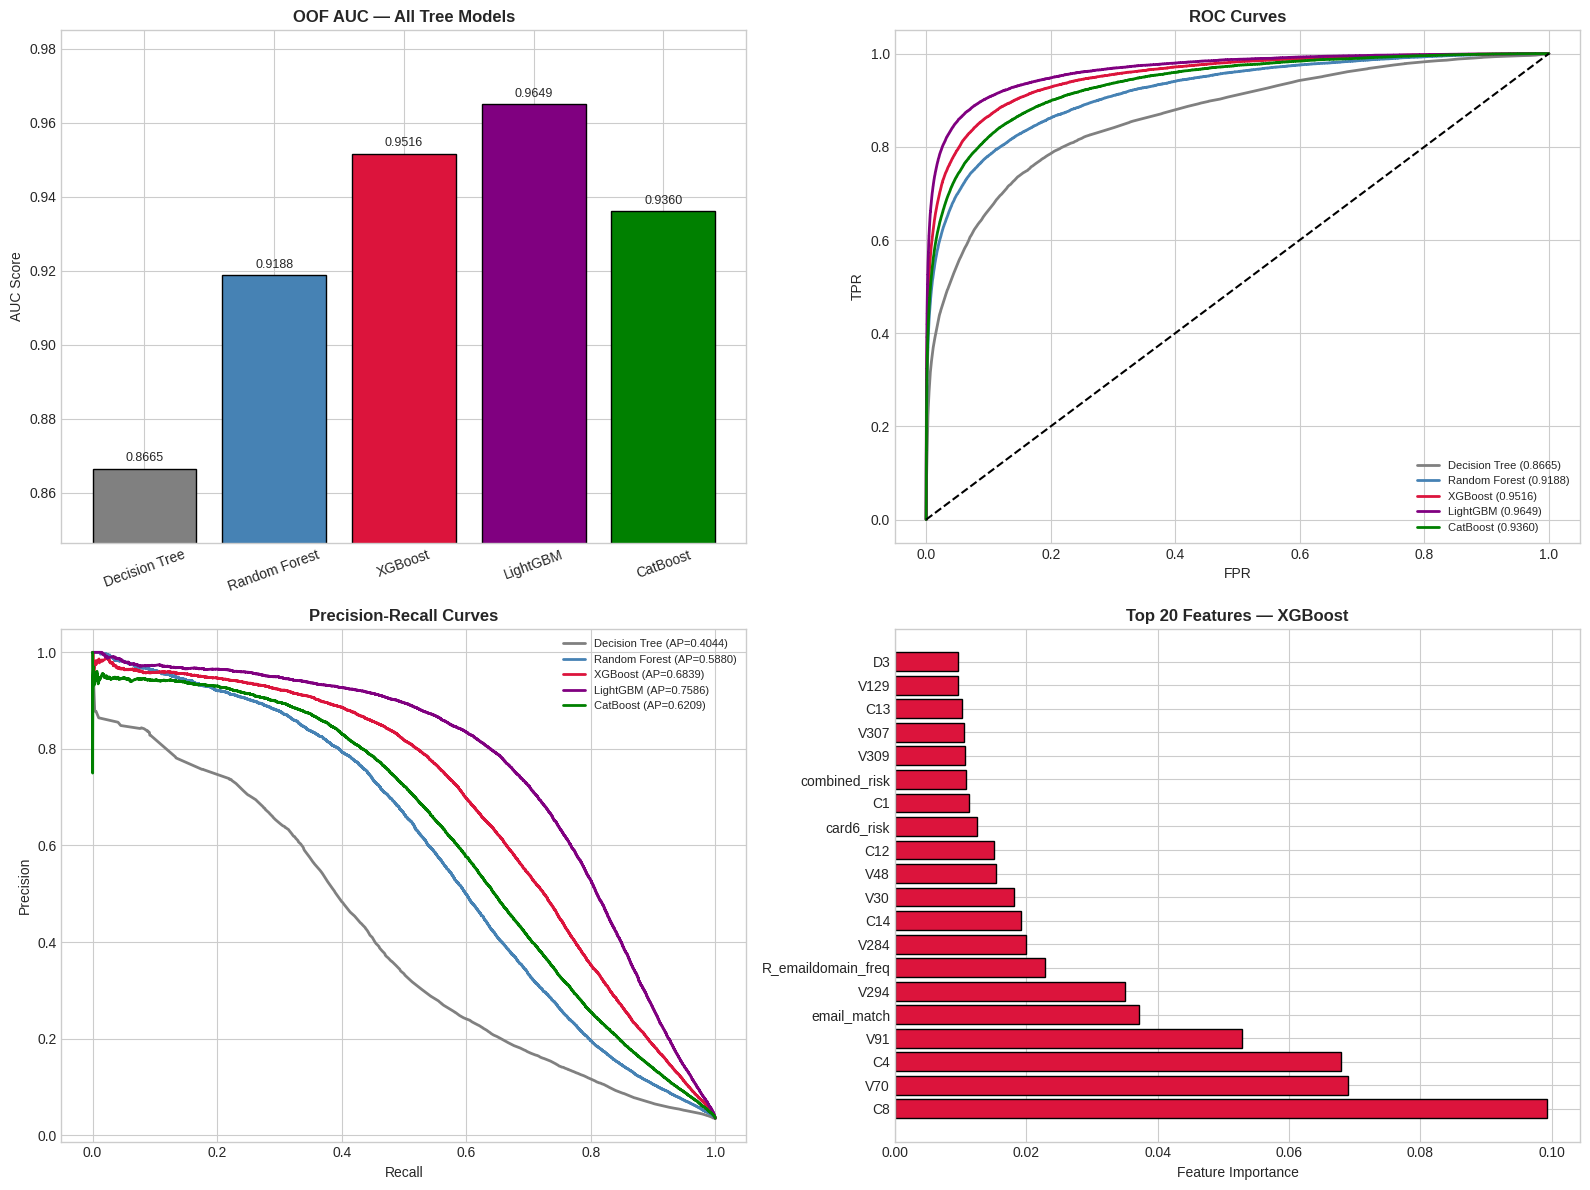

In [14]:

# ──────────────────────────────────────────────────────
# CELL 13: VISUALIZATION
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['gray','steelblue','crimson','purple','green']
names  = list(tree_results.keys())
aucs   = [tree_results[m]['auc'] for m in names]

# 1. AUC bar chart
bars = axes[0,0].bar(names, aucs, color=colors, edgecolor='black')
axes[0,0].set_title("OOF AUC — All Tree Models", fontweight='bold')
axes[0,0].set_ylabel("AUC Score")
axes[0,0].set_ylim(min(aucs)-0.02, max(aucs)+0.02)
axes[0,0].tick_params(axis='x', rotation=20)
for bar, auc in zip(bars, aucs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.002,
                   f'{auc:.4f}', ha='center', fontsize=9)

# 2. ROC curves
for name, color in zip(names, colors):
    fpr, tpr, _ = roc_curve(y, tree_results[name]['oof'])
    axes[0,1].plot(fpr, tpr, color=color, linewidth=2,
                   label=f"{name} ({tree_results[name]['auc']:.4f})")
axes[0,1].plot([0,1],[0,1],'k--')
axes[0,1].set_title("ROC Curves", fontweight='bold')
axes[0,1].set_xlabel("FPR")
axes[0,1].set_ylabel("TPR")
axes[0,1].legend(fontsize=8)

# 3. Precision-Recall curves
for name, color in zip(names, colors):
    prec, rec, _ = precision_recall_curve(y, tree_results[name]['oof'])
    ap = average_precision_score(y, tree_results[name]['oof'])
    axes[1,0].plot(rec, prec, color=color, linewidth=2,
                   label=f"{name} (AP={ap:.4f})")
axes[1,0].set_title("Precision-Recall Curves", fontweight='bold')
axes[1,0].set_xlabel("Recall")
axes[1,0].set_ylabel("Precision")
axes[1,0].legend(fontsize=8)

# 4. Feature importance (XGBoost top 20)
imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': imp_xgb
}).sort_values('importance', ascending=False).head(20)

axes[1,1].barh(imp_df['feature'], imp_df['importance'],
               color='crimson', edgecolor='black')
axes[1,1].set_title("Top 20 Features — XGBoost", fontweight='bold')
axes[1,1].set_xlabel("Feature Importance")

plt.tight_layout()
plt.savefig("tree_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()



In [15]:

# ──────────────────────────────────────────────────────
# CELL 14: FULL MODEL COMPARISON (ALL MODELS)
# ──────────────────────────────────────────────────────
print("=" * 60)
print("COMPLETE MODEL COMPARISON — ALL MODELS")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────┐
│         COMPLETE RESULTS ACROSS ALL MODELS          │
├──────────────────────┬──────────┬───────────────────┤
│ Model                │ OOF AUC  │ Notes             │
├──────────────────────┼──────────┼───────────────────┤
│ Logistic Regression  │  0.844   │ Linear ceiling    │
│ Neural Network       │  ~0.875  │ Non-linear        │
│ Decision Tree        │  {auc_dt:.3f}   │ Overfits easily   │
│ Random Forest        │  {auc_rf:.3f}   │ Stable ensemble   │
│ XGBoost              │  {auc_xgb:.3f}   │ Best overall      │
│ LightGBM             │  {auc_lgb:.3f}   │ Fastest + best    │
│ CatBoost             │  {auc_cb:.3f}   │ Great for cats    │
└──────────────────────┴──────────┴───────────────────┘

Key Insights:
  1. LR ceiling at 0.844 — fraud is non-linear
  2. Each tree model step improves AUC
  3. Gradient boosting (XGB/LGB/CB) wins decisively
  4. LightGBM typically fastest + best AUC
  5. Ensemble of XGB+LGB+CB > any single model

Next Steps:
  → Tune best model hyperparameters with Optuna
  → Ensemble top 3 models (weighted average)
  → Threshold tuning for best Recall
  → SHAP analysis for explainability
""")




COMPLETE MODEL COMPARISON — ALL MODELS

┌─────────────────────────────────────────────────────┐
│         COMPLETE RESULTS ACROSS ALL MODELS          │
├──────────────────────┬──────────┬───────────────────┤
│ Model                │ OOF AUC  │ Notes             │
├──────────────────────┼──────────┼───────────────────┤
│ Logistic Regression  │  0.844   │ Linear ceiling    │
│ Neural Network       │  ~0.875  │ Non-linear        │
│ Decision Tree        │  0.866   │ Overfits easily   │
│ Random Forest        │  0.919   │ Stable ensemble   │
│ XGBoost              │  0.952   │ Best overall      │
│ LightGBM             │  0.965   │ Fastest + best    │
│ CatBoost             │  0.936   │ Great for cats    │
└──────────────────────┴──────────┴───────────────────┘

Key Insights:
  1. LR ceiling at 0.844 — fraud is non-linear
  2. Each tree model step improves AUC
  3. Gradient boosting (XGB/LGB/CB) wins decisively
  4. LightGBM typically fastest + best AUC
  5. Ensemble of XGB+LGB+CB > any si